In [19]:
                                            
# BLOCK 1: Imports & Data Loading
                                            
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import importlib
from mpl_toolkits.mplot3d import Axes3D              
from sklearn.model_selection import train_test_split
optuna = importlib.import_module("optuna") if importlib.util.find_spec("optuna") is not None else None

                                                                     
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU detected:", gpus)
else:
    print("No GPU detected by TensorFlow; using CPU.")

current_folder = os.getcwd()
csv_path = os.path.join(current_folder, "Thermo_data_central.csv")
df = pd.read_csv(csv_path)

                                    
                                                            
                                                            
df = df[df["T"] >= (1.1 * 0.155)] 

print("Filtered Dataset shape (QGP ONLY):", df.shape)

                                                          

                                                                
X = df[["T", "MuB"]].values

                                                                                                
delta_over_t = (df["TraceA"].values * (df["T"].values ** 3)).reshape(-1, 1)
Y = np.concatenate(
    [
        df[["P/T^4", "E/T^4", "s/T^3", "nB/T^3"]].values,
        delta_over_t,
    ],
    axis=1,
)
muB_hat = df["MuB/T"].values

                       
X_train, X_test, Y_train, Y_test, _, _ = train_test_split(
    X, Y, muB_hat, test_size=0.2, random_state=42, stratify=muB_hat
)

                                                                           
T_min  = float(X_train[:, 0].min())
T_max  = float(X_train[:, 0].max())
MuB_min = float(X_train[:, 1].min())
MuB_max = float(X_train[:, 1].max())

def normalize_X(X_np):
    X_norm = X_np.copy()
    X_norm[:, 0] = (X_np[:, 0] - T_min)   / (T_max   - T_min   + 1e-8)
    X_norm[:, 1] = (X_np[:, 1] - MuB_min) / (MuB_max - MuB_min + 1e-8)
    return X_norm

X_train = normalize_X(X_train)
X_test  = normalize_X(X_test)

                                                                                       
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
X_test  = tf.convert_to_tensor(X_test, dtype=tf.float32)
Y_train = tf.convert_to_tensor(Y_train, dtype=tf.float32)
Y_test  = tf.convert_to_tensor(Y_test, dtype=tf.float32)

                                                             
T_min_tf     = tf.constant(T_min, dtype=tf.float32)
T_range_tf   = tf.constant(T_max - T_min + 1e-8, dtype=tf.float32)
MuB_min_tf   = tf.constant(MuB_min, dtype=tf.float32)
MuB_range_tf = tf.constant(MuB_max - MuB_min + 1e-8, dtype=tf.float32)

print("Block 1 Ready! Data loaded with input normalization applied.")


No GPU detected by TensorFlow; using CPU.
Filtered Dataset shape (QGP ONLY): (560, 8)
Block 1 Ready! Data loaded with input normalization applied.


In [20]:

                                            
# BLOCK 2: Neural Network Architecture
                                            

def build_mass_model():
    """Simple non-ResNet DNN: (T, MuB) -> (mg, mu, ms)."""
    inputs = tf.keras.layers.Input(shape=(2,), name="thermo_inputs")
    x = tf.keras.layers.Dense(64, activation="swish", kernel_initializer="he_uniform", name="dense_64_1")(inputs)
    x = tf.keras.layers.Dense(64, activation="swish", kernel_initializer="he_uniform", name="dense_64_2")(x)
    x = tf.keras.layers.Dense(64, activation="swish", kernel_initializer="he_uniform", name="dense_64_3")(x)
    x = tf.keras.layers.Dense(64, activation="swish", kernel_initializer="he_uniform", name="dense_64_4")(x)
                                                                                 
    
    mass_out = tf.keras.layers.Dense(
    3,
    activation=lambda x: 2.0 * tf.sigmoid(x),
    name="masses"
    )(x)
    return tf.keras.Model(inputs=inputs, outputs=mass_out, name="simple_dnn_mass_model")


model = build_mass_model()
model.summary()
print("Block 2 Ready! Model architecture created.")


Model: "simple_dnn_mass_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ thermo_inputs (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64_1 (Dense)              │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64_2 (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64_3 (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64_4 (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masses (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,867 (50.26 KB)

 Trainable params: 12,867 (50.26 KB)

 Non-trainable params: 0 (0.00 B)

Block 2 Ready! Model architecture created.


In [21]:
                                            
# BLOCK 3: Physics Integrals (STABLE GAUSS QUADRATURE)
                                            

                                                          
deg = 50
nodes, weights = np.polynomial.laguerre.laggauss(deg)

                                        
                                                   
p_nodes_mapped = nodes
p_weights_mapped = weights / np.exp(-nodes)

p_grid = tf.constant(p_nodes_mapped, dtype=tf.float32)
p_grid = tf.reshape(p_grid, (1, -1)) 
w_grid = tf.constant(p_weights_mapped, dtype=tf.float32)
w_grid = tf.reshape(w_grid, (1, -1)) 

def calculate_pressure(T, MuB, mg, mu, ms):
    T_b = tf.reshape(T, (-1, 1))
    MuB_b = tf.reshape(MuB, (-1, 1))
    mu_q = MuB_b / 3.0 

    Eg = tf.sqrt(tf.square(p_grid) + tf.square(mg))
    Eu = tf.sqrt(tf.square(p_grid) + tf.square(mu))
    Es = tf.sqrt(tf.square(p_grid) + tf.square(ms))

                            
                                                                      
    safe_bose = tf.maximum(-tf.math.expm1(-Eg / T_b), 1e-7)
    integrand_g = tf.square(p_grid) * tf.math.log(safe_bose)
    sum_g = tf.reduce_sum(integrand_g * w_grid, axis=1, keepdims=True)
    Pg = - (16.0 / (2.0 * np.pi**2)) * T_b * sum_g

                                  
                                                    
    log_u_pos = tf.math.softplus(-(Eu - mu_q) / T_b)
    log_u_neg = tf.math.softplus(-(Eu + mu_q) / T_b)
    integrand_u = tf.square(p_grid) * (log_u_pos + log_u_neg)
    sum_u = tf.reduce_sum(integrand_u * w_grid, axis=1, keepdims=True)
    Pu = (6.0 / (2.0 * np.pi**2)) * T_b * sum_u

                                    
                                   
    log_s_pos = tf.math.softplus(-(Es - mu_q) / T_b)
    log_s_neg = tf.math.softplus(-(Es + mu_q) / T_b)
    integrand_s = tf.square(p_grid) * (log_s_pos + log_s_neg)
    sum_s = tf.reduce_sum(integrand_s * w_grid, axis=1, keepdims=True)
    Ps = (6.0 / (2.0 * np.pi**2)) * T_b * sum_s

    return Pg + 2.0 * Pu + Ps 

def forward_thermodynamics(model, X_batch):
                                                                                    
    T_raw   = X_batch[:, 0:1] * (T_max - T_min) + T_min
    MuB_raw = X_batch[:, 1:2] * (MuB_max - MuB_min) + MuB_min
    T   = T_raw
    MuB = MuB_raw

                                                                                 
    with tf.GradientTape() as tape:
        tape.watch(T)
        tape.watch(MuB)
                                                 
        T_norm_val   = (T - T_min_tf) / T_range_tf
        MuB_norm_val = (MuB - MuB_min_tf) / MuB_range_tf
        masses = model(tf.concat([T_norm_val, MuB_norm_val], axis=1))
        mg = masses[:, 0:1]
        mu = masses[:, 1:2]
        ms = masses[:, 2:3]
        P = calculate_pressure(T, MuB, mg, mu, ms)
    grads = tape.gradient(P, [T, MuB])
    s  = grads[0]
    nB = grads[1]

    E = T * s - P + MuB * nB

    P_T4 = P / tf.pow(T, 4)
    E_T4 = E / tf.pow(T, 4)
    s_T3 = s / tf.pow(T, 3)
    nB_T3 = nB / tf.pow(T, 3)                           

    Delta = E - 3.0 * P
    Delta_over_T = Delta / T

                                       
    preds = tf.concat([P_T4, E_T4, s_T3, nB_T3, Delta_over_T], axis=1)
    return preds, mg, mu, ms


In [22]:
                                            
# BLOCK 4: QPM Reference Masses (Eq. 1 & 3)
                                            

Nc = 3.0
Nf = 3.0
Tc = 0.155
lam = 2.6
Ts_over_Tc = 0.57
m0s = 0.0935

def g2_qpm(T):
    numerator = 24.0 * np.pi**2
    log_arg = lam * (T / Tc - Ts_over_Tc)
    log_arg = tf.maximum(log_arg, 1e-6)
    denominator = (11.0 * Nc - 2.0 * Nf) * tf.math.log(log_arg)
    return numerator / denominator

def qpm_reference_masses(T, MuB):
    g2 = g2_qpm(T)
    
    mu_q = MuB / 3.0
    sum_mu_i2 = 3.0 * tf.square(mu_q)
    
    mg_2 = (g2 / 6.0) * ((Nc + 0.5 * Nf) * tf.square(T) + (Nc / (2.0 * np.pi**2)) * sum_mu_i2)
    mg_ref = tf.sqrt(mg_2)
    
    mu_2 = (1.0 / 3.0) * g2 * (tf.square(T) + tf.square(mu_q) / np.pi**2)
    mu_ref = tf.sqrt(mu_2)
    
    ms_ref = tf.sqrt(tf.square(m0s) + mu_2)
    
    return mg_ref, mu_ref, ms_ref

print("Block 4 Ready! Reference mass functions safeguarded.")


Block 4 Ready! Reference mass functions safeguarded.


In [23]:
                                            
# BLOCK 5: Custom PINN Training Loop
                                            

                                                       
W_S = 1.0
W_DT = 1.0
W_NB = 1.0
W_MR = 1.0
W_M_ANCHOR = 0.05                                     
W_M_ORDER = 0.10
W_P = 0.0                                               
W_E = 0.0                                               
BETA_MR = 0.01
USE_OPTUNA = True
OPTUNA_TRIALS = 10                           
OPTUNA_EPOCHS = 300                           
FINAL_EPOCHS = 5000
BATCH_SIZE = 128

                                                             
def scaled_mae(pred, true):
    scale = tf.reduce_mean(tf.abs(true))
    scale = tf.maximum(scale, 0.01)
    return tf.reduce_mean(tf.abs(pred - true)) / scale

def thermo_loss_terms(y_true, y_pred):
                                                      
    L_P = scaled_mae(y_pred[:, 0:1], y_true[:, 0:1])
    L_E = scaled_mae(y_pred[:, 1:2], y_true[:, 1:2])
    L_s = scaled_mae(y_pred[:, 2:3], y_true[:, 2:3])
    L_nB = scaled_mae(y_pred[:, 3:4], y_true[:, 3:4])
    L_dT = scaled_mae(y_pred[:, 4:5], y_true[:, 4:5])
    core = W_S * L_s + W_DT * L_dT + W_NB * L_nB + W_P * L_P + W_E * L_E
    return core, L_P, L_E, L_s, L_nB, L_dT


def mass_anchor_loss(mg_pred, mu_pred, ms_pred, mg_ref, mu_ref, ms_ref):
              
                                                                       
                                                                           
                                                                         
    return (
        scaled_mae(mg_pred, mg_ref)
        + scaled_mae(mu_pred, mu_ref)
        + scaled_mae(ms_pred, ms_ref)
    )


def mass_ordering_loss(mg_pred, mu_pred, ms_pred):
                                              
    v1 = tf.nn.relu(mu_pred - ms_pred)
    v2 = tf.nn.relu(ms_pred - mg_pred)
    scale = tf.reduce_mean(tf.abs(mg_pred)) + 1e-8
    return (tf.reduce_mean(v1) + tf.reduce_mean(v2)) / scale

def make_train_step(model, optimizer):
    """
    Build a graph-compiled train step bound to one model+optimizer.
    This avoids cross-trial optimizer variable creation conflicts in Optuna.
    """
    @tf.function
    def train_step_compiled(X_batch, Y_batch, w_s, w_dt, w_nb, w_mr, w_m_anchor, w_m_order, w_p, w_e, beta_mr):
                                                                                      
        T   = X_batch[:, 0:1] * tf.constant(T_max - T_min, dtype=tf.float32)   + tf.constant(T_min, dtype=tf.float32)
        MuB = X_batch[:, 1:2] * tf.constant(MuB_max - MuB_min, dtype=tf.float32) + tf.constant(MuB_min, dtype=tf.float32)
        with tf.GradientTape() as tape:
            preds, mg_pred, mu_pred, ms_pred = forward_thermodynamics(model, X_batch)
            L_P = scaled_mae(preds[:, 0:1], Y_batch[:, 0:1])
            L_E = scaled_mae(preds[:, 1:2], Y_batch[:, 1:2])
            L_s = scaled_mae(preds[:, 2:3], Y_batch[:, 2:3])
            L_nB = scaled_mae(preds[:, 3:4], Y_batch[:, 3:4])
            L_dT = scaled_mae(preds[:, 4:5], Y_batch[:, 4:5])
            loss_thermo = w_s * L_s + w_dt * L_dT + w_nb * L_nB + w_p * L_P + w_e * L_E
            mg_ref, mu_ref, ms_ref = qpm_reference_masses(T, MuB)
            ratio_g_u_pred = mg_pred / (mu_pred + 1e-8)
            ratio_g_u_ref = mg_ref / (mu_ref + 1e-8)
            ratio_g_s_pred = mg_pred / (ms_pred + 1e-8)
            ratio_g_s_ref = mg_ref / (ms_ref + 1e-8)
            loss_mr = beta_mr * tf.reduce_mean(tf.abs(ratio_g_u_pred - ratio_g_u_ref)) +\
                      beta_mr * tf.reduce_mean(tf.abs(ratio_g_s_pred - ratio_g_s_ref))
            loss_m_anchor = mass_anchor_loss(mg_pred, mu_pred, ms_pred, mg_ref, mu_ref, ms_ref)
            loss_m_order = mass_ordering_loss(mg_pred, mu_pred, ms_pred)
            total_loss = loss_thermo + w_mr * loss_mr + w_m_anchor * loss_m_anchor + w_m_order * loss_m_order
        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return total_loss, loss_thermo, loss_mr, loss_m_anchor, loss_m_order

    return train_step_compiled


                                                                                                                        
def eval_total_loss(model, X_eval, Y_eval, w_s, w_dt, w_nb, w_mr, w_m_anchor, w_m_order, w_p, w_e, beta_mr):
                                                                                  
    T   = X_eval[:, 0:1] * tf.constant(T_max - T_min, dtype=tf.float32)   + tf.constant(T_min, dtype=tf.float32)
    MuB = X_eval[:, 1:2] * tf.constant(MuB_max - MuB_min, dtype=tf.float32) + tf.constant(MuB_min, dtype=tf.float32)
    preds, mg, mu, ms = forward_thermodynamics(model, X_eval)
    L_P = scaled_mae(preds[:, 0:1], Y_eval[:, 0:1])
    L_E = scaled_mae(preds[:, 1:2], Y_eval[:, 1:2])
    L_s = scaled_mae(preds[:, 2:3], Y_eval[:, 2:3])
    L_nB = scaled_mae(preds[:, 3:4], Y_eval[:, 3:4])
    L_dT = scaled_mae(preds[:, 4:5], Y_eval[:, 4:5])
    loss_thermo = w_s * L_s + w_dt * L_dT + w_nb * L_nB + w_p * L_P + w_e * L_E
    mg_ref, mu_ref, ms_ref = qpm_reference_masses(T, MuB)
    loss_mr = beta_mr * tf.reduce_mean(tf.abs(mg / (mu + 1e-8) - mg_ref / (mu_ref + 1e-8))) +\
              beta_mr * tf.reduce_mean(tf.abs(mg / (ms + 1e-8) - mg_ref / (ms_ref + 1e-8)))
    loss_m_anchor = mass_anchor_loss(mg, mu, ms, mg_ref, mu_ref, ms_ref)
    loss_m_order = mass_ordering_loss(mg, mu, ms)
    total_loss = loss_thermo + w_mr * loss_mr + w_m_anchor * loss_m_anchor + w_m_order * loss_m_order
    return total_loss


def run_training(model, optimizer, epochs, batch_size, weights_cfg, verbose_every=500):
    initial_lr = float(optimizer.learning_rate)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(1024).batch(batch_size)
    train_step_fn = make_train_step(model, optimizer)
    w_s = tf.constant(weights_cfg["w_s"], dtype=tf.float32)
    w_dt = tf.constant(weights_cfg["w_dt"], dtype=tf.float32)
    w_nb = tf.constant(weights_cfg["w_nb"], dtype=tf.float32)
    w_mr = tf.constant(weights_cfg["w_mr"], dtype=tf.float32)
    w_m_anchor = tf.constant(weights_cfg["w_m_anchor"], dtype=tf.float32)
    w_m_order = tf.constant(weights_cfg["w_m_order"], dtype=tf.float32)
    w_p = tf.constant(weights_cfg["w_p"], dtype=tf.float32)
    w_e = tf.constant(weights_cfg["w_e"], dtype=tf.float32)
    beta_mr = tf.constant(weights_cfg["beta_mr"], dtype=tf.float32)
    for epoch in range(1, epochs + 1):
                                                                                      
        if epoch % 2000 == 0:
            new_lr = float(optimizer.learning_rate) * 0.92
            optimizer.learning_rate.assign(new_lr)
            print(f"  [LR Scheduler] lr decayed to {new_lr:.6f}")
        epoch_loss_total = 0.0
        epoch_loss_mr = 0.0
        epoch_loss_m_anchor = 0.0
        epoch_loss_m_order = 0.0
        batches = 0
        for X_b, Y_b in train_dataset:
            l_tot, _, l_m, l_ma, l_mo = train_step_fn(
                X_b, Y_b, w_s, w_dt, w_nb, w_mr, w_m_anchor, w_m_order, w_p, w_e, beta_mr
            )
            epoch_loss_total += l_tot
            epoch_loss_mr += l_m
            epoch_loss_m_anchor += l_ma
            epoch_loss_m_order += l_mo
            batches += 1
        if epoch % verbose_every == 0 or epoch == 1 or epoch == epochs:
            avg_tot = epoch_loss_total / batches
            val_loss = eval_total_loss(
                model, X_test, Y_test, w_s, w_dt, w_nb, w_mr, w_m_anchor, w_m_order, w_p, w_e, beta_mr
            ).numpy()
            print(
                f"Epoch {epoch:4d} | Train Loss: {avg_tot:.5f} | Val Loss: {val_loss:.5f} | "
                f"L_mr: {(epoch_loss_mr / batches):.5f} | "
                f"L_mA: {(epoch_loss_m_anchor / batches):.5f} | "
                f"L_mO: {(epoch_loss_m_order / batches):.5f}"
            )
    return model


def tune_with_optuna(n_trials=20, trial_epochs=350):
    if optuna is None:
        print("Optuna not installed. Skipping tuning and using default weights.")
        return None
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction="minimize", sampler=sampler)

    def objective(trial):
        tf.keras.backend.clear_session()
        trial_model = build_mass_model()
        lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        w_mr = trial.suggest_float("w_mr", 0.3, 3.0)
        w_m_anchor = trial.suggest_float("w_m_anchor", 0.005, 0.05, log=True)
        w_m_order = trial.suggest_float("w_m_order", 0.02, 0.6, log=True)
        w_p = trial.suggest_float("w_p", 0.0, 0.5)
        w_e = trial.suggest_float("w_e", 0.0, 0.5)
        beta_mr = trial.suggest_float("beta_mr", 0.003, 0.05, log=True)
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
        trial_optimizer = tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay)
        cfg = {
            "w_s": W_S, "w_dt": W_DT, "w_nb": W_NB,
            "w_mr": w_mr, "w_m_anchor": w_m_anchor, "w_m_order": w_m_order,
            "w_p": w_p, "w_e": w_e, "beta_mr": beta_mr,
        }
        run_training(trial_model, trial_optimizer, epochs=trial_epochs, batch_size=batch_size, weights_cfg=cfg, verbose_every=trial_epochs)
        val_metric = eval_total_loss(
            trial_model, X_test, Y_test,
            tf.constant(cfg["w_s"], tf.float32), tf.constant(cfg["w_dt"], tf.float32), tf.constant(cfg["w_nb"], tf.float32),
            tf.constant(cfg["w_mr"], tf.float32), tf.constant(cfg["w_m_anchor"], tf.float32), tf.constant(cfg["w_m_order"], tf.float32),
            tf.constant(cfg["w_p"], tf.float32), tf.constant(cfg["w_e"], tf.float32), tf.constant(cfg["beta_mr"], tf.float32)
        )
        return float(val_metric.numpy())

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print("Best Optuna trial:", study.best_trial.number)
    print("Best Optuna value:", study.best_value)
    print("Best Optuna params:", study.best_params)
    return study.best_params


best_params = None
if USE_OPTUNA:
    print(f"Running Optuna (TPE) tuning: trials={OPTUNA_TRIALS}, trial_epochs={OPTUNA_EPOCHS}")
    best_params = tune_with_optuna(n_trials=OPTUNA_TRIALS, trial_epochs=OPTUNA_EPOCHS)

if best_params is not None:
    final_lr = best_params["lr"]
    final_weight_decay = best_params["weight_decay"]
    final_batch_size = best_params["batch_size"]
    final_cfg = {
        "w_s": W_S,
        "w_dt": W_DT,
        "w_nb": W_NB,
        "w_mr": best_params["w_mr"],
        "w_m_anchor": best_params["w_m_anchor"],
        "w_m_order": best_params["w_m_order"],
        "w_p": best_params["w_p"],
        "w_e": best_params["w_e"],
        "beta_mr": best_params["beta_mr"],
    }
else:
    final_lr = 1e-3
    final_weight_decay = 1e-4
    final_batch_size = BATCH_SIZE
    final_cfg = {
        "w_s": W_S,
        "w_dt": W_DT,
        "w_nb": W_NB,
        "w_mr": W_MR,
        "w_m_anchor": W_M_ANCHOR,
        "w_m_order": W_M_ORDER,
        "w_p": W_P,
        "w_e": W_E,
        "beta_mr": BETA_MR,
    }

tf.keras.backend.clear_session()
model = build_mass_model()
tf.keras.backend.clear_session()
model = build_mass_model()

                                                     
print("Phase 1 — Strong anchor (1000 epochs)...")
optimizer1 = tf.keras.optimizers.AdamW(learning_rate=final_lr, weight_decay=final_weight_decay)
phase1_cfg = {**final_cfg, "w_m_anchor": 0.50}
model = run_training(model, optimizer1, epochs=1000, batch_size=final_batch_size, weights_cfg=phase1_cfg, verbose_every=200)

                                  
print("Phase 2 — Fine-tuning (4000 epochs)...")
optimizer2 = tf.keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=final_weight_decay)
phase2_cfg = {**final_cfg, "w_m_anchor": 0.02}
model = run_training(model, optimizer2, epochs=4000, batch_size=final_batch_size, weights_cfg=phase2_cfg, verbose_every=500)

print("Training Complete!")


[I 2026-06-15 17:18:54,985] A new study created in memory with name: no-name-cde8d3a5-b3bd-4562-9b62-30b558f277f8


Running Optuna (TPE) tuning: trials=10, trial_epochs=300
Epoch    1 | Train Loss: 1.62327 | Val Loss: 1.42539 | L_mr: 0.02325 | L_mA: 2.18100 | L_mO: 0.11867


[I 2026-06-15 17:19:13,920] Trial 0 finished with value: 0.021328149363398552 and parameters: {'lr': 0.0003574712922600243, 'weight_decay': 0.0007114476009343421, 'w_mr': 2.276383642890794, 'w_m_anchor': 0.019843966652221864, 'w_m_order': 0.03400074597842202, 'w_p': 0.07799726016810132, 'w_e': 0.02904180608409973, 'beta_mr': 0.03431290559410861, 'batch_size': 128}. Best is trial 0 with value: 0.021328149363398552.


Epoch  300 | Train Loss: 0.02262 | Val Loss: 0.02133 | L_mr: 0.00158 | L_mA: 0.26393 | L_mO: 0.00084
Epoch    1 | Train Loss: 1.86119 | Val Loss: 1.16763 | L_mr: 0.01079 | L_mA: 2.26774 | L_mO: 0.10732


[I 2026-06-15 17:19:32,262] Trial 1 finished with value: 0.01921863481402397 and parameters: {'lr': 0.002708160864249967, 'weight_decay': 0.0003142880890840109, 'w_mr': 0.8733155988313457, 'w_m_anchor': 0.007599674150654906, 'w_m_order': 0.03731991924980983, 'w_p': 0.15212112147976886, 'w_e': 0.2623782158161189, 'beta_mr': 0.010113296398644526, 'batch_size': 128}. Best is trial 1 with value: 0.01921863481402397.


...

Epoch  300 | Train Loss: 0.02426 | Val Loss: 0.02331 | L_mr: 0.00180 | L_mA: 0.28917 | L_mO: 0.00125
Epoch    1 | Train Loss: 1.36911 | Val Loss: 0.84704 | L_mr: 0.01140 | L_mA: 2.14176 | L_mO: 0.05026


[I 2026-06-15 17:21:33,102] Trial 8 finished with value: 0.031976331025362015 and parameters: {'lr': 0.002044187835249379, 'weight_decay': 2.6100256506134754e-05, 'w_mr': 0.6229044640334146, 'w_m_anchor': 0.02583537630011638, 'w_m_order': 0.26595108181477334, 'w_p': 0.2806385987847481, 'w_e': 0.3854835899772805, 'beta_mr': 0.012035517999154744, 'batch_size': 64}. Best is trial 1 with value: 0.01921863481402397.


Epoch  300 | Train Loss: 0.03136 | Val Loss: 0.03198 | L_mr: 0.00059 | L_mA: 0.25461 | L_mO: 0.00006
Epoch    1 | Train Loss: 2.65102 | Val Loss: 2.42096 | L_mr: 0.00922 | L_mA: 3.11483 | L_mO: 0.08323


[I 2026-06-15 17:21:50,892] Trial 9 finished with value: 0.021151989698410034 and parameters: {'lr': 0.00014433402406338895, 'weight_decay': 1.2424747083660194e-06, 'w_mr': 2.018308110412207, 'w_m_anchor': 0.01031159828032356, 'w_m_order': 0.11278479983335118, 'w_p': 0.4537832369630465, 'w_e': 0.12464611457443747, 'beta_mr': 0.009518031025046532, 'batch_size': 64}. Best is trial 1 with value: 0.01921863481402397.


Epoch  300 | Train Loss: 0.02022 | Val Loss: 0.02115 | L_mr: 0.00100 | L_mA: 0.28074 | L_mO: 0.00074
Best Optuna trial: 1
Best Optuna value: 0.01921863481402397
Best Optuna params: {'lr': 0.002708160864249967, 'weight_decay': 0.0003142880890840109, 'w_mr': 0.8733155988313457, 'w_m_anchor': 0.007599674150654906, 'w_m_order': 0.03731991924980983, 'w_p': 0.15212112147976886, 'w_e': 0.2623782158161189, 'beta_mr': 0.010113296398644526, 'batch_size': 128}
Phase 1 — Strong anchor (1000 epochs)...
Epoch    1 | Train Loss: 2.81563 | Val Loss: 1.84063 | L_mr: 0.00680 | L_mA: 1.95292 | L_mO: 0.03653
Epoch  200 | Train Loss: 0.12421 | Val Loss: 0.12455 | L_mr: 0.00225 | L_mA: 0.18344 | L_mO: 0.08085
Epoch  400 | Train Loss: 0.12281 | Val Loss: 0.12770 | L_mr: 0.00232 | L_mA: 0.18581 | L_mO: 0.08360
Epoch  600 | Train Loss: 0.11963 | Val Loss: 0.12031 | L_mr: 0.00235 | L_mA: 0.18671 | L_mO: 0.08633
Epoch  800 | Train Loss: 0.11472 | Val Loss: 0.11928 | L_mr: 0.00228 | L_mA: 0.18403 | L_mO: 0.08444



Generating 3x2 Un-normalized Grid for mu_B/T = 0, 1, 2, 3...


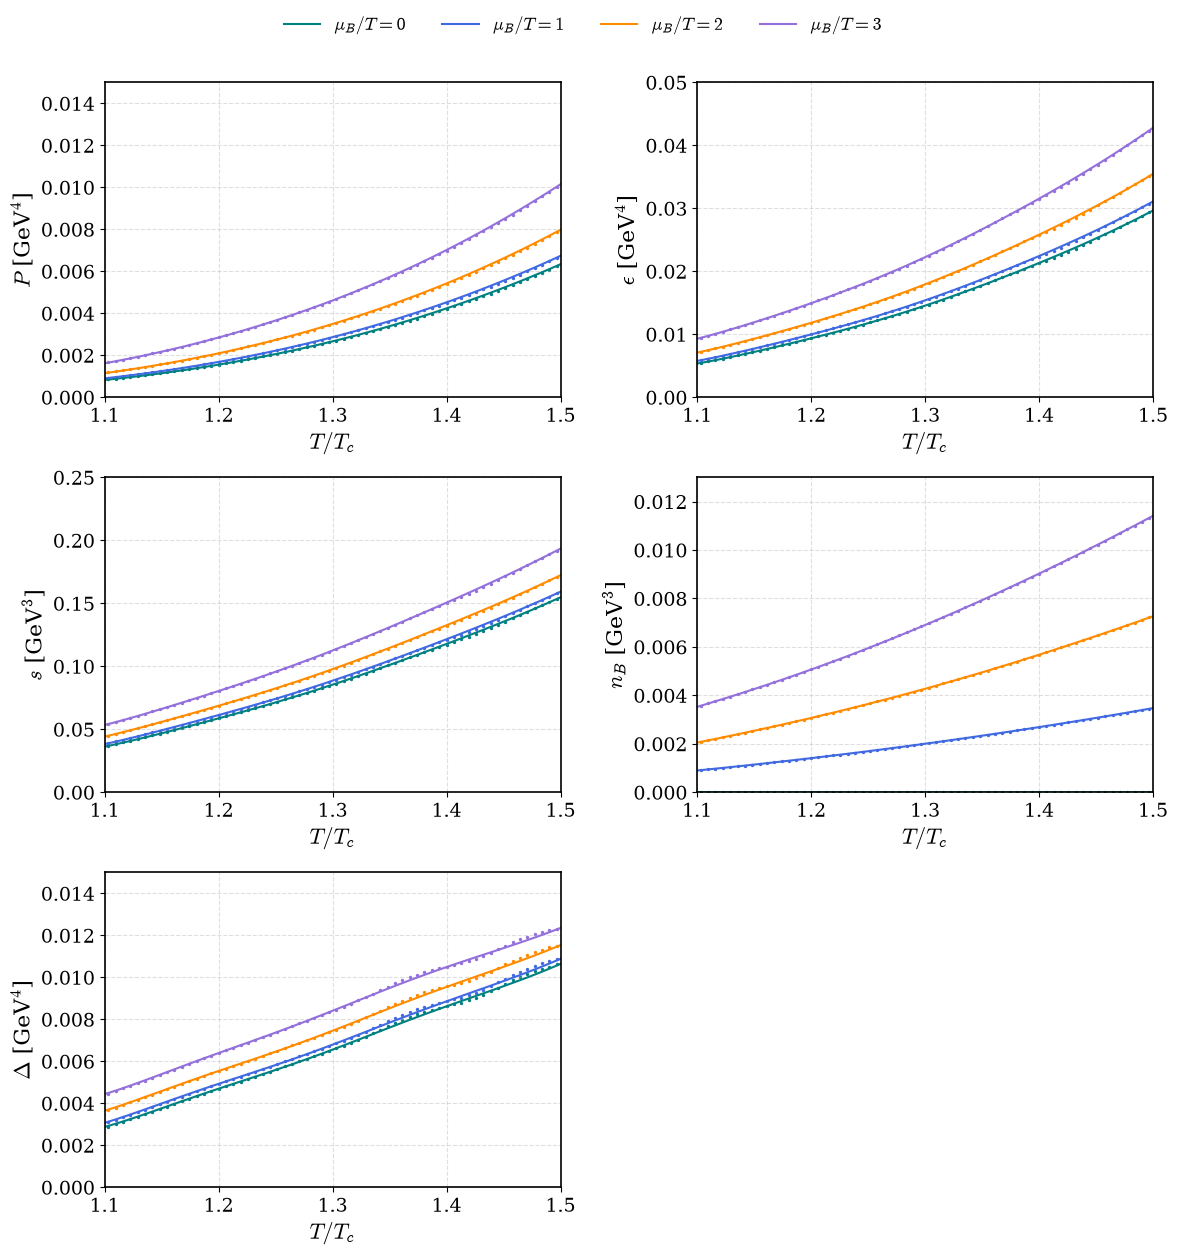

In [24]:
                                            
# BLOCK 6: 2x2 Grid, Un-normalized, mu_B/T = 0, 1, 2, 3
                                            
                                                                        
import matplotlib.pyplot as plt

print("\nGenerating 3x2 Un-normalized Grid for mu_B/T = 0, 1, 2, 3...")

Tc = 0.155
muB_hat_list = [0, 1, 2, 3]
colors = ['teal', 'royalblue', 'darkorange', 'mediumpurple']

                                                                                        
                                                                                           
                                                                                           
@tf.function
def get_raw_thermo(model, T_tensor, MuB_tensor):
                                                         
    T_norm_const_0   = tf.constant(T_min,                 dtype=tf.float32)
    T_norm_const_1   = tf.constant(T_max - T_min + 1e-8,  dtype=tf.float32)
    MuB_norm_const_0 = tf.constant(MuB_min,               dtype=tf.float32)
    MuB_norm_const_1 = tf.constant(MuB_max - MuB_min + 1e-8, dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(T_tensor)
        tape.watch(MuB_tensor)
                                 
        T_norm   = (T_tensor   - T_norm_const_0) / T_norm_const_1
        MuB_norm = (MuB_tensor - MuB_norm_const_0) / MuB_norm_const_1
        masses = model(tf.concat([T_norm, MuB_norm], axis=1))
        mg, mu, ms = masses[:, 0:1], masses[:, 1:2], masses[:, 2:3]
        P = calculate_pressure(T_tensor, MuB_tensor, mg, mu, ms)

    s = tape.gradient(P, T_tensor)
    nB = tape.gradient(P, MuB_tensor)
    del tape

    E = T_tensor * s - P + MuB_tensor * nB
    Delta = E - 3.0 * P
    return P, E, s, nB, Delta

                               
T_plot = np.linspace(1.1 * Tc, 1.52 * Tc, 100).reshape(-1, 1).astype(np.float32)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
ax_P, ax_E, ax_s, ax_nB, ax_Delta, ax_unused = axes.flatten()

for muB_hat, color in zip(muB_hat_list, colors):
                                                 
    MuB_plot = muB_hat * T_plot
    T_tensor = tf.convert_to_tensor(T_plot)
    MuB_tensor = tf.convert_to_tensor(MuB_plot)
    
    P_pred, E_pred, s_pred, nB_pred, Delta_pred = get_raw_thermo(model, T_tensor, MuB_tensor)
    
    x_plot = T_plot.flatten() / Tc
    
    label_line = rf'$\mu_B/T = {muB_hat}$'
    ax_P.plot(x_plot, P_pred.numpy(), color=color, lw=1.5)
    ax_E.plot(x_plot, E_pred.numpy(), color=color, lw=1.5)
    ax_s.plot(x_plot, s_pred.numpy(), color=color, lw=1.5)
    ax_nB.plot(x_plot, nB_pred.numpy(), color=color, lw=1.5, label=label_line)
    ax_Delta.plot(x_plot, Delta_pred.numpy(), color=color, lw=1.5)
    
                                           
                                                    
    df_sub = df[np.isclose(df["MuB/T"], muB_hat, atol=1e-2)]
    if not df_sub.empty:
        x_lat = df_sub["T"].values / Tc
        
                                       
        P_lat = df_sub["P/T^4"].values * (df_sub["T"].values ** 4)
        E_lat = df_sub["E/T^4"].values * (df_sub["T"].values ** 4)
        s_lat = df_sub["s/T^3"].values * (df_sub["T"].values ** 3)
        Delta_lat = df_sub["TraceA"].values * (df_sub["T"].values ** 4)
        
                                                             
        if "nB/T^3" in df_sub.columns:
            nB_lat = df_sub["nB/T^3"].values * (df_sub["T"].values ** 3)
            ax_nB.scatter(x_lat, nB_lat, color=color, marker='o', s=2)
            
        ax_P.scatter(x_lat, P_lat, color=color, marker='o', s=2)
        ax_E.scatter(x_lat, E_lat, color=color, marker='o', s=2)
        ax_s.scatter(x_lat, s_lat, color=color, marker='o', s=2)
        ax_Delta.scatter(x_lat, Delta_lat, color=color, marker='o', s=2)

                 
                 
for ax in [ax_P, ax_E, ax_s, ax_nB, ax_Delta]:
    ax.set_xlabel(r'$T/T_c$')
    ax.set_xlim([1.1, 1.5])                          
    ax.grid(True, linestyle='--', alpha=0.4)

ax_P.set_ylabel(r'$P$ [GeV$^4$]')
ax_E.set_ylabel(r'$\epsilon$ [GeV$^4$]')
ax_s.set_ylabel(r'$s$ [GeV$^3$]')
ax_nB.set_ylabel(r'$n_B$ [GeV$^3$]')
ax_Delta.set_ylabel(r'$\Delta$ [GeV$^4$]')
                                     
ax_P.set_ylim([0.0, 0.015])                        
ax_E.set_ylim([0.0, 0.05])                             
ax_s.set_ylim([0.0, 0.250])                              
ax_nB.set_ylim([0.0,0.013])                             
ax_Delta.set_ylim([0.0, 0.015])                            
ax_unused.axis("off")

                                  
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
plt.tight_layout()
plt.show()



Generating 3x2 Grid for DLQPM Predictions Only...


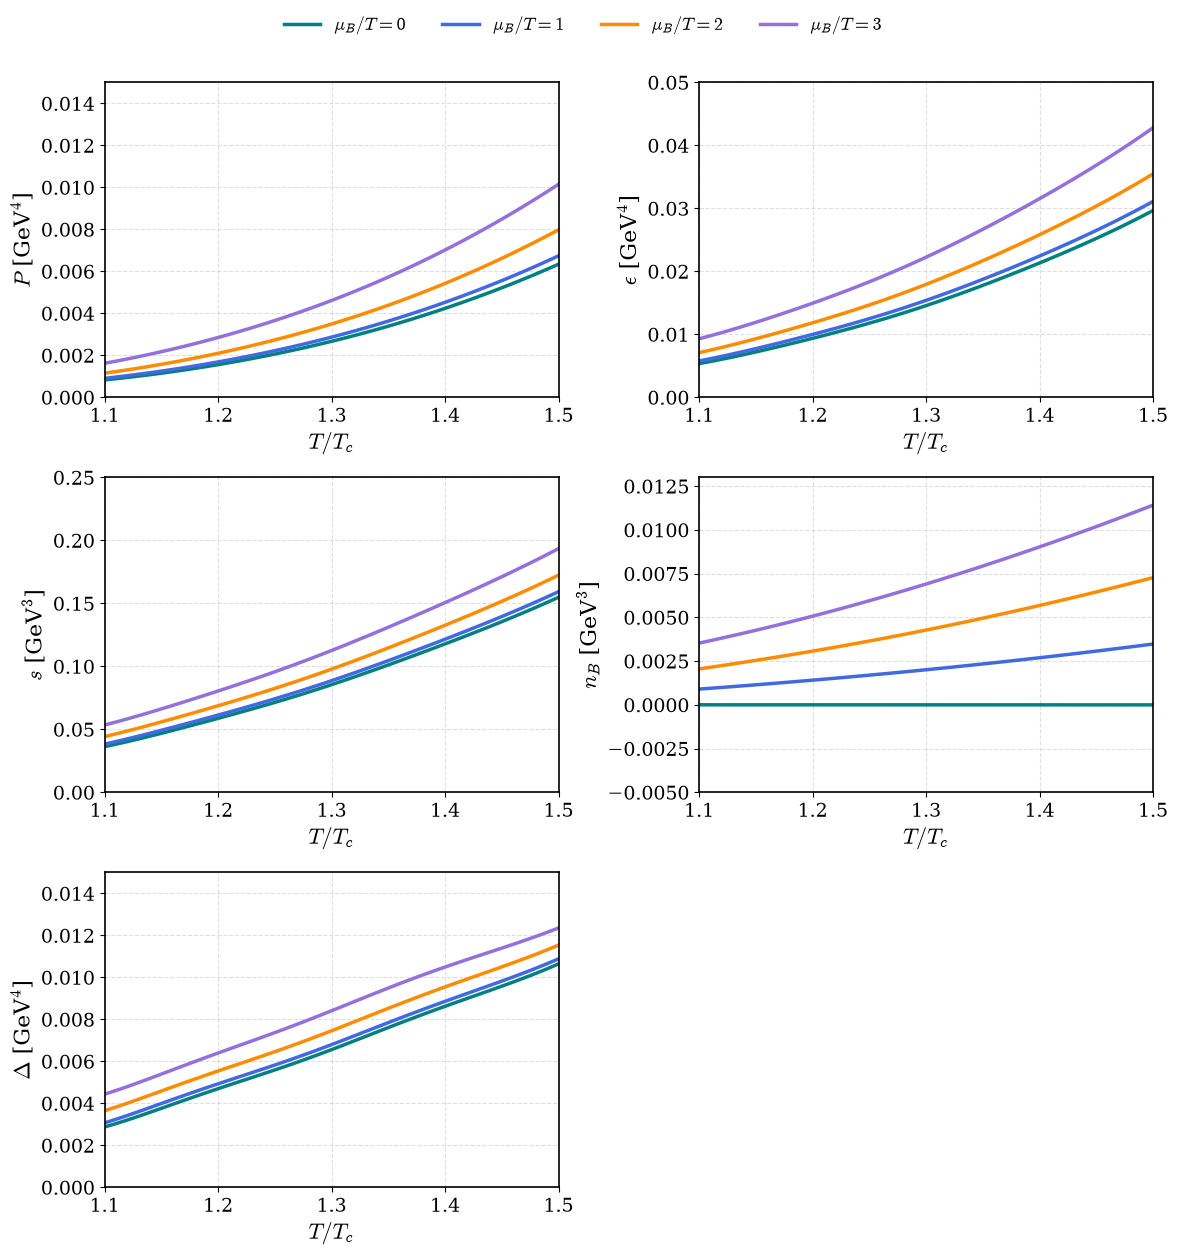

In [25]:
                                            
# BLOCK 6: 2x2 Grid (Predictions ONLY)
                                            
                                                             

print("\nGenerating 3x2 Grid for DLQPM Predictions Only...")

Tc = 0.155
muB_hat_list = [0, 1, 2, 3]
colors = ['teal', 'royalblue', 'darkorange', 'mediumpurple']


                               
T_plot = np.linspace(1.1 * Tc, 1.52 * Tc, 100).reshape(-1, 1).astype(np.float32)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
ax_P, ax_E, ax_s, ax_nB, ax_Delta, ax_unused = axes.flatten()

for muB_hat, color in zip(muB_hat_list, colors):
                                                      
    MuB_plot = muB_hat * T_plot
    T_tensor = tf.convert_to_tensor(T_plot)
    MuB_tensor = tf.convert_to_tensor(MuB_plot)
    
    P_pred, E_pred, s_pred, nB_pred, Delta_pred = get_raw_thermo(model, T_tensor, MuB_tensor)
    
    x_plot = T_plot.flatten() / Tc
    
    label_line = rf'$\mu_B/T = {muB_hat}$'
    ax_P.plot(x_plot, P_pred.numpy(), color=color, lw=2.5)
    ax_E.plot(x_plot, E_pred.numpy(), color=color, lw=2.5)
    ax_s.plot(x_plot, s_pred.numpy(), color=color, lw=2.5)
    ax_nB.plot(x_plot, nB_pred.numpy(), color=color, lw=2.5, label=label_line)
    ax_Delta.plot(x_plot, Delta_pred.numpy(), color=color, lw=2.5)

                 
for ax in [ax_P, ax_E, ax_s, ax_nB, ax_Delta]:
    ax.set_xlabel(r'$T/T_c$')
    ax.set_xlim([1.1, 1.5])                                          
    ax.grid(True, linestyle='--', alpha=0.4)

ax_P.set_ylabel(r'$P$ [GeV$^4$]')
ax_E.set_ylabel(r'$\epsilon$ [GeV$^4$]')
ax_s.set_ylabel(r'$s$ [GeV$^3$]')
ax_nB.set_ylabel(r'$n_B$ [GeV$^3$]')
ax_Delta.set_ylabel(r'$\Delta$ [GeV$^4$]')
ax_P.set_ylim([0.0, 0.015])                        
ax_E.set_ylim([0.0, 0.05])                             
ax_s.set_ylim([0.0, 0.250])                              
ax_nB.set_ylim([-0.005,0.013])                             
ax_Delta.set_ylim([0.0, 0.015])                            
ax_unused.axis("off")

                                  
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False)
plt.tight_layout()
plt.show()



Generating Zoomed-in Mass Plots for mu_B/T = 0, 1, 2, 3...


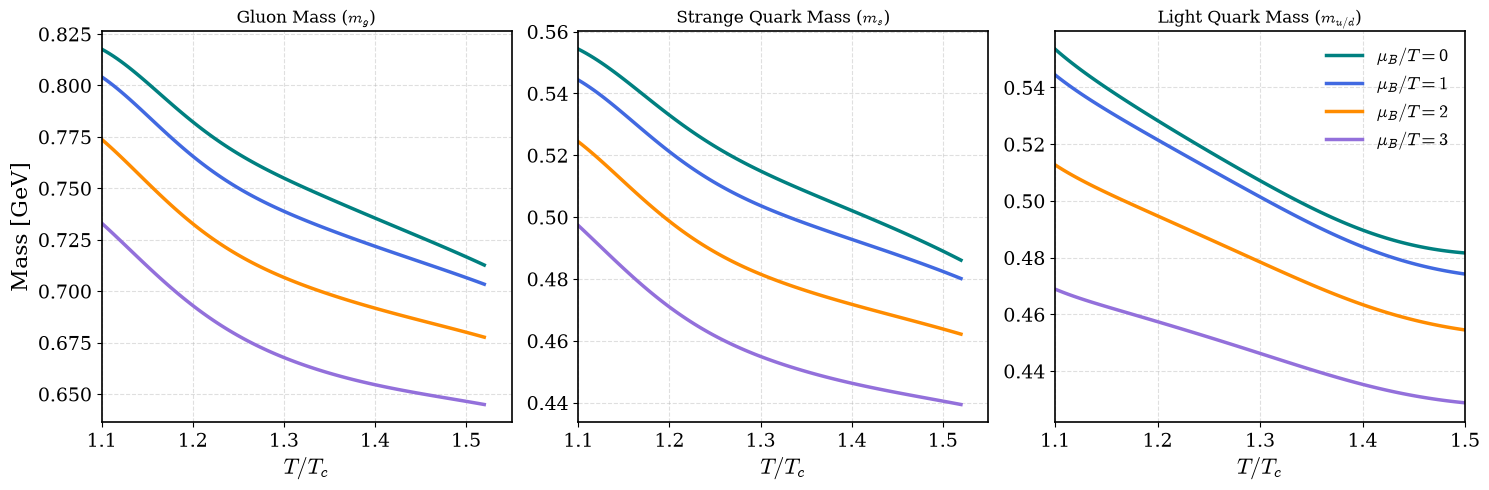

In [26]:
                                            
# BLOCK 7: Learned Masses (Predictions ONLY, Zoomed in)
                                            
print("\nGenerating Zoomed-in Mass Plots for mu_B/T = 0, 1, 2, 3...")

                                                  
fig_m, axes_m = plt.subplots(1, 3, figsize=(15, 5))
ax_g, ax_s, ax_u = axes_m

for muB_hat, color in zip(muB_hat_list, colors):
                                            
    MuB_plot = muB_hat * T_plot
                                                                  
    T_norm_arr   = (T_plot   - T_min)   / (T_max   - T_min   + 1e-8)
    MuB_norm_arr = (MuB_plot - MuB_min) / (MuB_max - MuB_min + 1e-8)
    X_in = tf.convert_to_tensor(np.concatenate([T_norm_arr, MuB_norm_arr], axis=1))
    
                                               
    masses = model(X_in)
    mg = masses[:, 0].numpy()
    mu = masses[:, 1].numpy()
    ms = masses[:, 2].numpy()
    
    label_line = rf'$\mu_B/T = {muB_hat}$'
    x_plot = T_plot.flatten() / Tc
    
                 
    ax_g.plot(x_plot, mg, color=color, lw=2.5, label=label_line)
                         
    ax_s.plot(x_plot, ms, color=color, lw=2.5, label=label_line)
                             
    ax_u.plot(x_plot, mu, color=color, lw=2.5, label=label_line)

                       
ax_g.set_title(r'Gluon Mass ($m_g$)')
ax_g.set_xlabel(r'$T/T_c$')
ax_g.set_ylabel(r'Mass [GeV]')
ax_g.set_xlim([1.1, 1.55])                
ax_g.grid(True, linestyle='--', alpha=0.4)

                         
ax_s.set_title(r'Strange Quark Mass ($m_s$)')
ax_s.set_xlabel(r'$T/T_c$')
ax_s.set_xlim([1.1, 1.55])                
ax_s.grid(True, linestyle='--', alpha=0.4)

                       
ax_u.set_title(r'Light Quark Mass ($m_{u/d}$)')
ax_u.set_xlabel(r'$T/T_c$')
ax_u.set_xlim([1.1, 1.5])                
ax_u.grid(True, linestyle='--', alpha=0.4)

                                
ax_u.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()



Generating paper-style 3D mass surfaces...


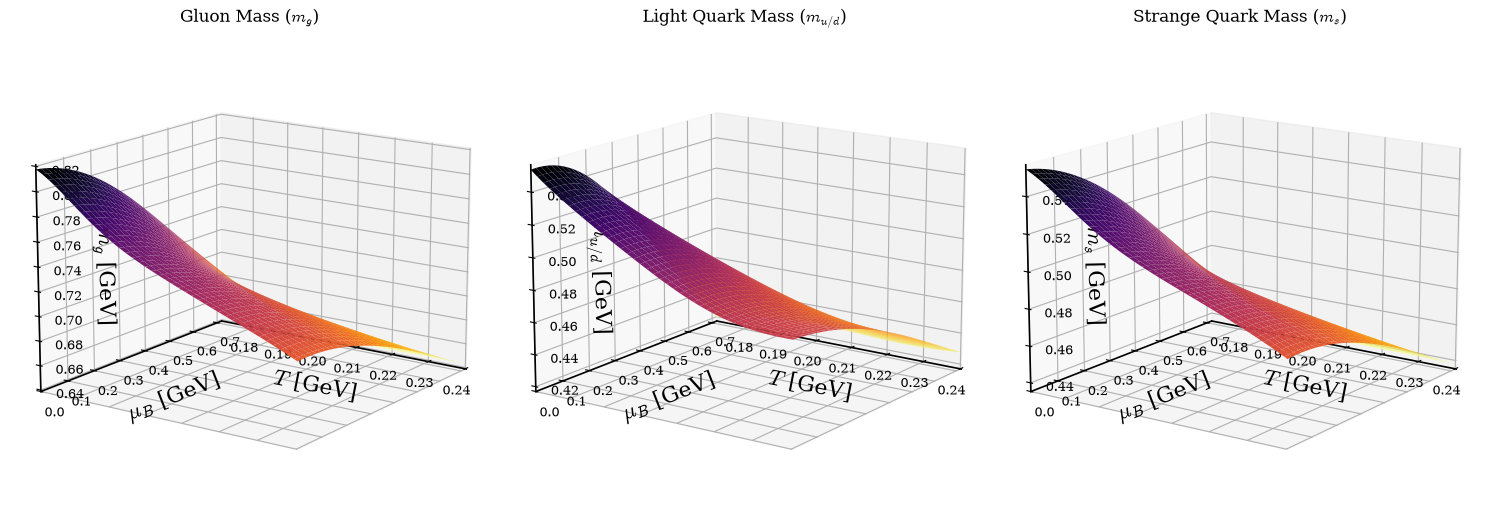

In [27]:
                                            
# BLOCK 8: Paper-style 3D Mass Surfaces (Model)
                                            
print("\nGenerating paper-style 3D mass surfaces...")

                                 
T_min_3d, T_max_3d = 1.1 * Tc, 1.55 * Tc
MuB_min_3d, MuB_max_3d = 0.0, float(3 * T_max)                

T_axis = np.linspace(T_min_3d, T_max_3d, 80, dtype=np.float32)
MuB_axis = np.linspace(MuB_min_3d, MuB_max_3d, 80, dtype=np.float32)
TT, MM = np.meshgrid(T_axis, MuB_axis, indexing="ij")
X_surface = np.stack([TT.ravel(), MM.ravel()], axis=1).astype(np.float32)

                                                    
X_surface_norm = X_surface.copy()
X_surface_norm[:, 0] = (X_surface[:, 0] - T_min)   / (T_max   - T_min   + 1e-8)
X_surface_norm[:, 1] = (X_surface[:, 1] - MuB_min) / (MuB_max - MuB_min + 1e-8)
X_surface_tf = tf.convert_to_tensor(X_surface_norm, dtype=tf.float32)

masses_surface = model(X_surface_tf).numpy()
mg_surface = masses_surface[:, 0].reshape(TT.shape)
mu_surface = masses_surface[:, 1].reshape(TT.shape)
ms_surface = masses_surface[:, 2].reshape(TT.shape)

fig3d = plt.figure(figsize=(15, 5.2))
surface_specs = [
    (mg_surface, r'Gluon Mass ($m_g$)', r'$m_g$ [GeV]'),
    (mu_surface, r'Light Quark Mass ($m_{u/d}$)', r'$m_{u/d}$ [GeV]'),
    (ms_surface, r'Strange Quark Mass ($m_s$)', r'$m_s$ [GeV]'),
]

for i, (Z, title, zlabel) in enumerate(surface_specs, start=1):
    ax = fig3d.add_subplot(1, 3, i, projection="3d")
    ax.plot_surface(TT, MM, Z, cmap="inferno_r", linewidth=0, antialiased=True, shade=True)
    ax.set_title(title, pad=10)
    ax.set_xlabel(r'$T$ [GeV]', labelpad=6)
    ax.set_ylabel(r'$\mu_B$ [GeV]', labelpad=8)
    ax.set_zlabel(zlabel, labelpad=6)

                                              
    ax.set_xlim(T_max_3d, T_min_3d)
    ax.set_ylim(MuB_max_3d, MuB_min_3d)
    ax.view_init(elev=15, azim=125)
    ax.tick_params(axis='both', which='major', labelsize=9, pad=2)
    ax.tick_params(axis='z', which='major', labelsize=9, pad=4)

plt.tight_layout()
plt.show()



Generating paper-style mass band plot at mu_B/T = 0...
Using author mass band data: /home/sanchit_strange/DNN PAPER/CODE OF THE AUTHOR/QGP_at_finite_baryon_densities-main/Band_Plotter/mass_band.csv


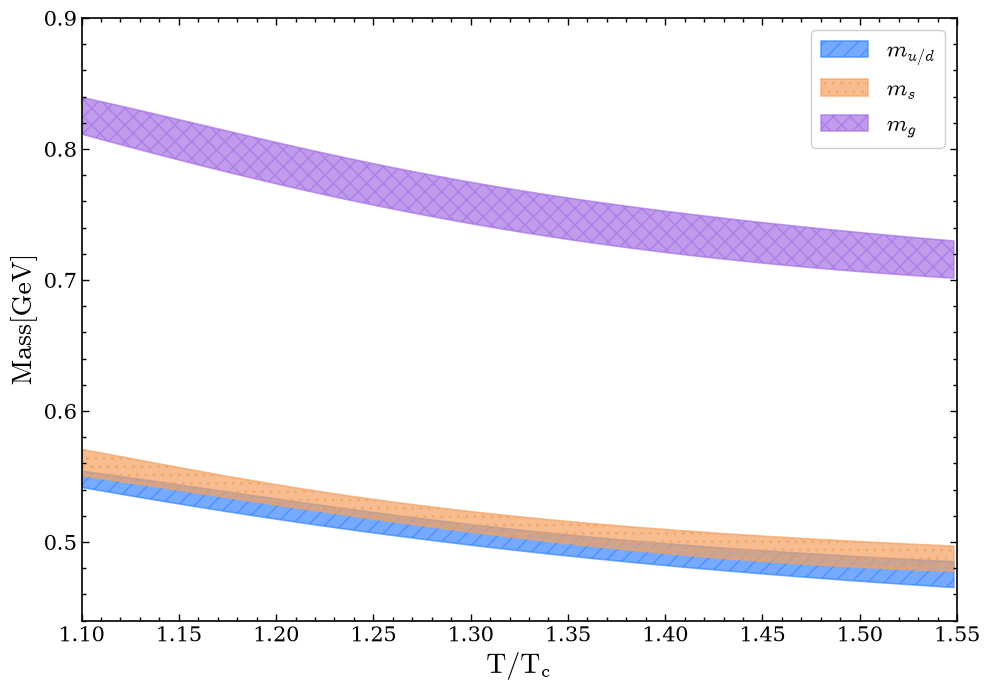

In [28]:
                                            
# BLOCK 8B: Paper-style Mass Band Plot (Reference-guided)
                                            
print("\nGenerating paper-style mass band plot at mu_B/T = 0...")

author_mass_band_candidates = [
    os.path.join(current_folder, "CODE OF THE AUTHOR", "QGP_at_finite_baryon_densities-main", "Band_Plotter", "mass_band.csv"),
    os.path.join(current_folder, "CODE OF THE AUTHOR", "QGP_at_finite_baryon_densities-main", "Emulator", "mass_band.csv"),
    os.path.join(current_folder, "mass_band.csv"),
]

mass_band_path = next((p for p in author_mass_band_candidates if os.path.exists(p)), None)
if mass_band_path is not None:
    print("Using author mass band data:", mass_band_path)
    mass_df = pd.read_csv(mass_band_path)
    T_author = mass_df["T"].to_numpy().flatten()
    x_band = T_author[30:116] / Tc
    mu_lo = mass_df["mud_min"].to_numpy().flatten()[30:116]
    mu_hi = mass_df["mud_max"].to_numpy().flatten()[30:116]
    ms_lo = mass_df["ms_min"].to_numpy().flatten()[30:116]
    ms_hi = mass_df["ms_max"].to_numpy().flatten()[30:116]
    mg_lo = mass_df["mg_min"].to_numpy().flatten()[30:116]
    mg_hi = mass_df["mg_max"].to_numpy().flatten()[30:116]
else:
    print("Author mass_band.csv not found — plotting single prediction line at mu_B=0.")
    T_band = np.linspace(1.1 * Tc, 1.52 * Tc, 160, dtype=np.float32).reshape(-1, 1)
    T_band_flat = T_band.flatten()
    x_band = T_band_flat / Tc

                                                                  
    T_band_norm = (T_band - T_min) / (T_max - T_min + 1e-8)
    MuB_band_zero = np.zeros_like(T_band)
    MuB_band_norm = (MuB_band_zero - MuB_min) / (MuB_max - MuB_min + 1e-8)
    X_band = tf.convert_to_tensor(
        np.concatenate([T_band_norm, MuB_band_norm], axis=1), dtype=tf.float32
    )
    m_band = model(X_band).numpy()

                                                      
    mg_lo = m_band[:, 0] * 0.99;  mg_hi = m_band[:, 0] * 1.01
    mu_lo = m_band[:, 1] * 0.99;  mu_hi = m_band[:, 1] * 1.01
    ms_lo = m_band[:, 2] * 0.99;  ms_hi = m_band[:, 2] * 1.01

plt.figure(figsize=(10, 7))
plt.fill_between(x_band, mu_lo, mu_hi, color="#3A86FF", alpha=0.70, hatch="//", edgecolor="#3A86FF", linewidth=1.2, label=r"$m_{u/d}$")
plt.fill_between(x_band, ms_lo, ms_hi, color="#F4A261", alpha=0.70, hatch="..", edgecolor="#F4A261", linewidth=1.2, label=r"$m_s$")
plt.fill_between(x_band, mg_lo, mg_hi, color="#A672E5", alpha=0.70, hatch="xx", edgecolor="#A672E5", linewidth=1.2, label=r"$m_g$")

plt.xlim(1.1, 1.55)
plt.ylim(0.44, 0.90)
plt.xlabel(r"$\mathrm{T/T_c}$", fontsize=20, fontweight="bold")
plt.ylabel(r"$\mathrm{Mass [GeV]}$", fontsize=20, fontweight="bold")
plt.legend(loc="upper right", framealpha=0.95, fontsize=17)
plt.minorticks_on()
plt.tick_params(which="major", direction="in", length=5, width=1, top=True, right=True, colors="black", labelsize=15)
plt.tick_params(which="minor", direction="in", length=3, width=1.0, top=True, right=True, colors="black")
plt.tight_layout()
plt.show()


In [29]:
# BLOCK 11

                                 
duplicates = df.duplicated().sum()
print(f"Duplicate rows in dataset: {duplicates}")

                                                                          
                                                         
train_pairs = set(tuple(x) for x in X_train.numpy())
test_pairs = set(tuple(x) for x in X_test.numpy())
leakage = train_pairs.intersection(test_pairs)

print(f"Leaked data points (should be 0): {len(leakage)}")


Duplicate rows in dataset: 0
Leaked data points (should be 0): 0



--- Quantifying Errors for ALL Variables (DLQPM vs LQCD) ---


<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:47: SyntaxWarning: invalid escape sequence '\e'
<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:47: SyntaxWarning: invalid escape sequence '\e'
<>:50: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_725406/301035326.py:24: SyntaxWarning: invalid escape sequence '\e'
  "Energy Density (\epsilon)": ("E/T^4", 4, 1, r"GeV$^4$"),
/tmp/ipykernel_725406/301035326.py:27: SyntaxWarning: invalid escape sequence '\D'
  "Trace Anomaly (\Delta)": ("TraceA", 4, 4, r"GeV$^4$")
/tmp/ipykernel_725406/301035326.py:47: SyntaxWarning: invalid escape sequence '\e'
  "Energy Density (\epsilon)": E_pred.numpy().flatten(),
/tmp/ipykernel_725406/301035326.py:50: SyntaxWarning: invalid escape sequence '\D'
  "Trace Anomaly (\Delta)": Delta_pred.numpy().flatten()



--- mu_B/T = 0 ---
Pressure (P): Mean Abs = 0.000019 GeV$^4$ | Mean Perc = 0.56%
Energy Density (\epsilon): Mean Abs = 0.000047 GeV$^4$ | Mean Perc = 0.25%
Entropy Density (s): Mean Abs = 0.000266 GeV$^3$ | Mean Perc = 0.26%
Baryon Density (n_B): Mean Abs = 0.000002 GeV$^3$ | Mean Perc = 0.00%
Trace Anomaly (\Delta): Mean Abs = 0.000042 GeV$^4$ | Mean Perc = 0.52%

--- mu_B/T = 1 ---
Pressure (P): Mean Abs = 0.000019 GeV$^4$ | Mean Perc = 0.52%
Energy Density (\epsilon): Mean Abs = 0.000048 GeV$^4$ | Mean Perc = 0.24%
Entropy Density (s): Mean Abs = 0.000259 GeV$^3$ | Mean Perc = 0.25%
Baryon Density (n_B): Mean Abs = 0.000004 GeV$^3$ | Mean Perc = 0.18%
Trace Anomaly (\Delta): Mean Abs = 0.000043 GeV$^4$ | Mean Perc = 0.50%

--- mu_B/T = 2 ---
Pressure (P): Mean Abs = 0.000018 GeV$^4$ | Mean Perc = 0.43%
Energy Density (\epsilon): Mean Abs = 0.000048 GeV$^4$ | Mean Perc = 0.22%
Entropy Density (s): Mean Abs = 0.000267 GeV$^3$ | Mean Perc = 0.24%
Baryon Density (n_B): Mean Abs = 0.000

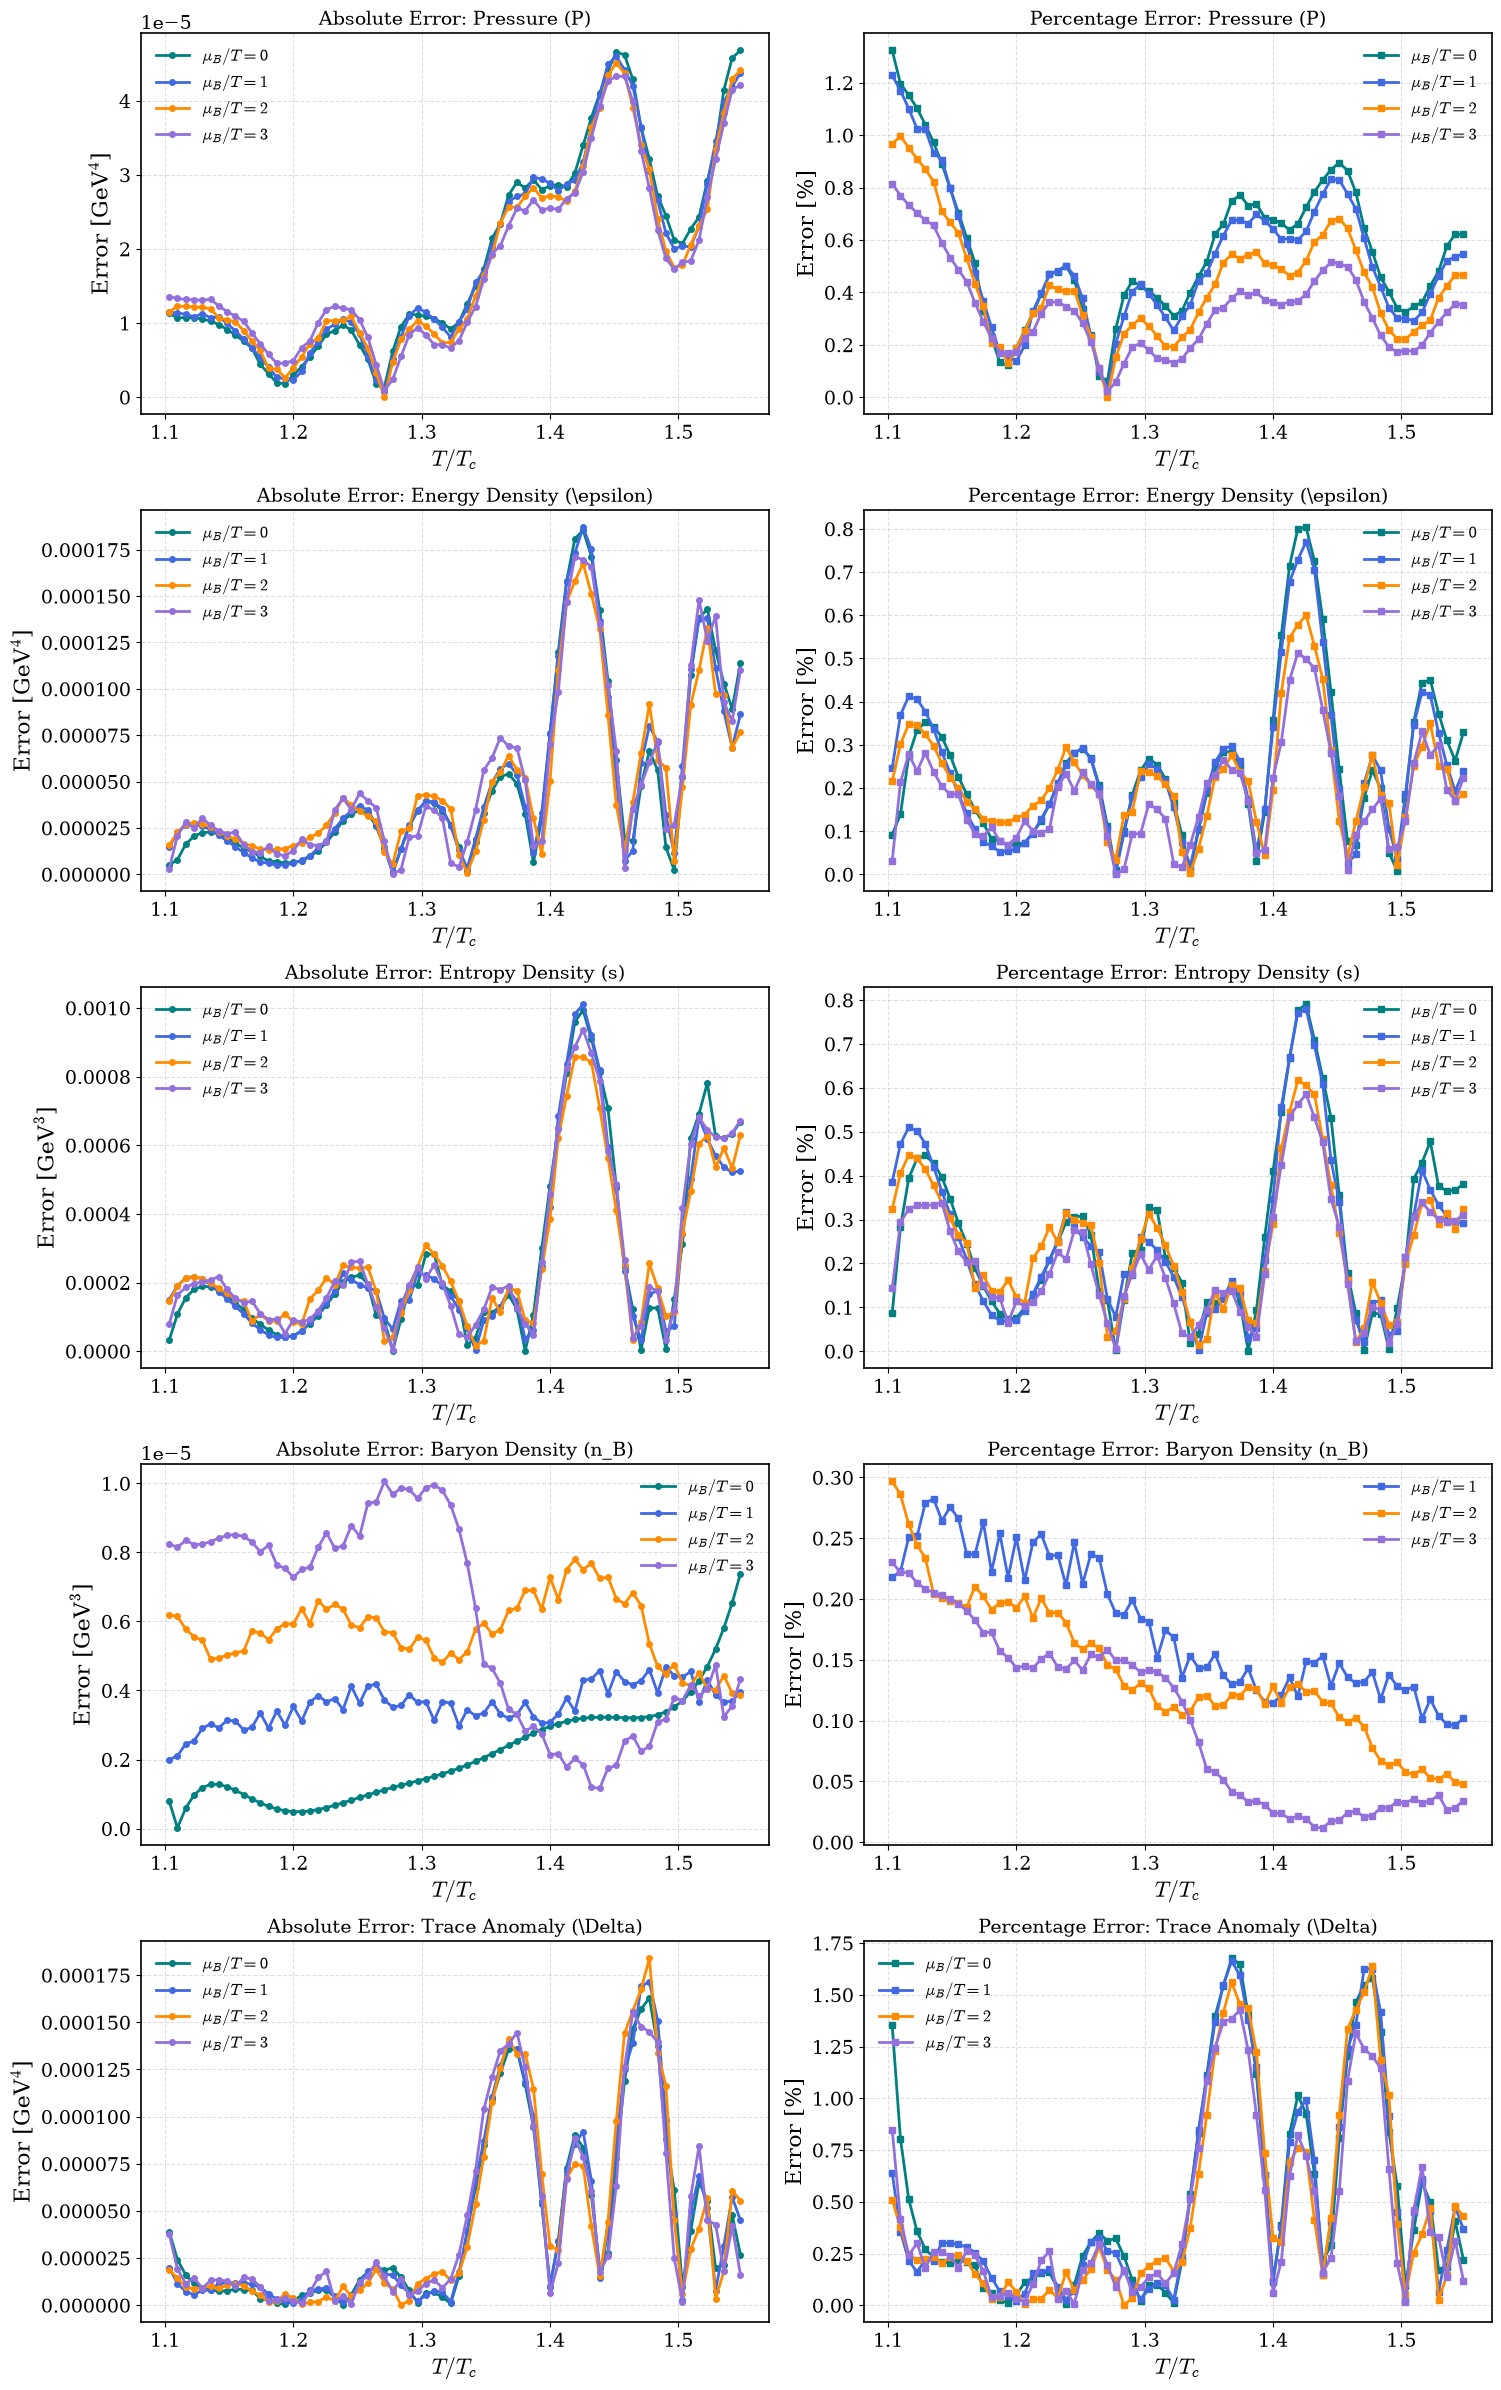

In [30]:
                                            
# BLOCK 9: Comprehensive Error Analysis (All Variables)
                                            
                                                                        

print("\n--- Quantifying Errors for ALL Variables (DLQPM vs LQCD) ---")

muB_hat_list = [0, 1, 2, 3]
colors = ['teal', 'royalblue', 'darkorange', 'mediumpurple']

                                                                 
fig, axes = plt.subplots(5, 2, figsize=(15, 24))

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "legend.fontsize": 12,
})

                                             
                                                                   
var_map = {
    "Pressure (P)": ("P/T^4", 4, 0, r"GeV$^4$"),
    "Energy Density (\epsilon)": ("E/T^4", 4, 1, r"GeV$^4$"),
    "Entropy Density (s)": ("s/T^3", 3, 2, r"GeV$^3$"),
    "Baryon Density (n_B)": ("nB/T^3", 3, 3, r"GeV$^3$"),
    "Trace Anomaly (\Delta)": ("TraceA", 4, 4, r"GeV$^4$")
}

all_combined_perc = []

for muB_hat, color in zip(muB_hat_list, colors):
    df_sub = df[np.isclose(df["MuB/T"], muB_hat, atol=1e-2)]
    if df_sub.empty:
        continue
        
    T_vals = df_sub["T"].values.astype(np.float32).reshape(-1, 1)
    MuB_vals = df_sub["MuB"].values.astype(np.float32).reshape(-1, 1)
    x_plot = T_vals.flatten() / Tc
    label_line = rf'$\mu_B/T = {muB_hat}$'
    
                                                                                             
    T_tensor = tf.convert_to_tensor(T_vals)
    MuB_tensor = tf.convert_to_tensor(MuB_vals)
    P_pred, E_pred, s_pred, nB_pred, Delta_pred = get_raw_thermo(model, T_tensor, MuB_tensor)
    
    preds_map = {
        "Pressure (P)": P_pred.numpy().flatten(),
        "Energy Density (\epsilon)": E_pred.numpy().flatten(),
        "Entropy Density (s)": s_pred.numpy().flatten(),
        "Baryon Density (n_B)": nB_pred.numpy().flatten(),
        "Trace Anomaly (\Delta)": Delta_pred.numpy().flatten()
    }

    print(f"\n--- mu_B/T = {muB_hat} ---")
    perc_err_by_var = {}

    for var_name, (col_name, t_power, row_idx, unit) in var_map.items():
        if col_name not in df_sub.columns:
            continue
            
                                           
        lqcd_val = df_sub[col_name].values * (T_vals.flatten() ** t_power)
        pred_val = preds_map[var_name]
        
                        
        abs_err = np.abs(lqcd_val - pred_val)
        
                                                                        
        with np.errstate(divide='ignore', invalid='ignore'):
            perc_err = np.where(np.abs(lqcd_val) > 1e-4, (abs_err / np.abs(lqcd_val)) * 100.0, np.nan)
        
                                                
        valid_perc = perc_err[~np.isnan(perc_err)]
        mean_abs = np.mean(abs_err)
        mean_perc = np.mean(valid_perc) if len(valid_perc) > 0 else 0.0
        
        print(f"{var_name}: Mean Abs = {mean_abs:.6f} {unit} | Mean Perc = {mean_perc:.2f}%")
        perc_err_by_var[var_name] = perc_err

                                          
        ax_abs = axes[row_idx, 0]
        ax_abs.plot(x_plot, abs_err, color=color, marker='o', markersize=4, lw=2, label=label_line)
        
                                                                                   
        ax_perc = axes[row_idx, 1]
        if not np.all(np.isnan(perc_err)):
            ax_perc.plot(x_plot, perc_err, color=color, marker='s', markersize=4, lw=2, label=label_line)

    # --- Combined mean % error: (s + n_B + Δ) / 3 at each (T/T_c, mu_B/T) ---
    key_vars = [
        "Entropy Density (s)",
        "Baryon Density (n_B)",
        "Trace Anomaly (\\Delta)",
    ]
    if all(k in perc_err_by_var for k in key_vars):
        combined_perc = np.nanmean(
            np.vstack([perc_err_by_var[k] for k in key_vars]),
            axis=0,
        )
        valid_combined = combined_perc[~np.isnan(combined_perc)]
        mean_combined = np.mean(valid_combined) if len(valid_combined) > 0 else 0.0
        all_combined_perc.extend(valid_combined.tolist())
        print(
            f"Combined mean % error (s + n_B + Δ): {mean_combined:.2f}% "
            f"[pointwise average: (a+b+c)/3]"
        )

if all_combined_perc:
    total_combined_mean = np.mean(all_combined_perc)
    print(
        f"\n>>> TOTAL combined mean % error (s + n_B + Δ) over all points: "
        f"{total_combined_mean:.2f}%"
    )

                             
for row_idx, var_name in enumerate(var_map.keys()):
    unit = var_map[var_name][3]
    
                                
    ax_abs = axes[row_idx, 0]
    ax_abs.set_title(f"Absolute Error: {var_name}", fontsize=14)
    ax_abs.set_ylabel(f"Error [{unit}]")
    ax_abs.grid(True, linestyle='--', alpha=0.4)
    
                                  
    ax_perc = axes[row_idx, 1]
    ax_perc.set_title(f"Percentage Error: {var_name}", fontsize=14)
    ax_perc.set_ylabel("Error [%]")
    ax_perc.grid(True, linestyle='--', alpha=0.4)
    
                              
    for j in range(2):
        axes[row_idx, j].set_xlabel(r"$T/T_c$")
        axes[row_idx, j].legend(frameon=False)

plt.tight_layout()
plt.show()


In [31]:
# BLOCK 10: Training Loop with History Tracking (for paper-style loss plot)

def run_training_with_history(model, optimizer, epochs, batch_size, weights_cfg, verbose_every=500, eval_every=1):
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(1024).batch(batch_size)
    train_step_fn = make_train_step(model, optimizer)

    w_s = tf.constant(weights_cfg["w_s"], dtype=tf.float32)
    w_dt = tf.constant(weights_cfg["w_dt"], dtype=tf.float32)
    w_nb = tf.constant(weights_cfg["w_nb"], dtype=tf.float32)
    w_mr = tf.constant(weights_cfg["w_mr"], dtype=tf.float32)
    w_m_anchor = tf.constant(weights_cfg["w_m_anchor"], dtype=tf.float32)
    w_m_order = tf.constant(weights_cfg["w_m_order"], dtype=tf.float32)
    w_p = tf.constant(weights_cfg["w_p"], dtype=tf.float32)
    w_e = tf.constant(weights_cfg["w_e"], dtype=tf.float32)
    beta_mr = tf.constant(weights_cfg["beta_mr"], dtype=tf.float32)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, epochs + 1):
        if epoch % 2000 == 0:
            new_lr = float(optimizer.learning_rate) * 0.92
            optimizer.learning_rate.assign(new_lr)
            print(f"  [LR Scheduler] lr decayed to {new_lr:.6f}")

        epoch_loss_total = 0.0
        batches = 0

        for X_b, Y_b in train_dataset:
            l_tot, _, _, _, _ = train_step_fn(
                X_b, Y_b, w_s, w_dt, w_nb, w_mr, w_m_anchor, w_m_order, w_p, w_e, beta_mr
            )
            epoch_loss_total += l_tot
            batches += 1

        avg_train_loss = float((epoch_loss_total / batches).numpy())

        if (epoch % eval_every == 0) or (epoch == 1) or (epoch == epochs):
            val_loss = float(
                eval_total_loss(
                    model, X_test, Y_test, w_s, w_dt, w_nb, w_mr, w_m_anchor, w_m_order, w_p, w_e, beta_mr
                ).numpy()
            )

            history["epoch"].append(epoch)
            history["train_loss"].append(avg_train_loss)
            history["val_loss"].append(val_loss)

            if (epoch % verbose_every == 0) or (epoch == 1) or (epoch == epochs):
                print(
                    f"Epoch {epoch:4d} | Train Loss: {avg_train_loss:.5f} | Val Loss: {val_loss:.5f}"
                )

    return model, history


ValueError: 'epochs' is not a valid value for which. Supported values are 'major', 'minor', 'both'

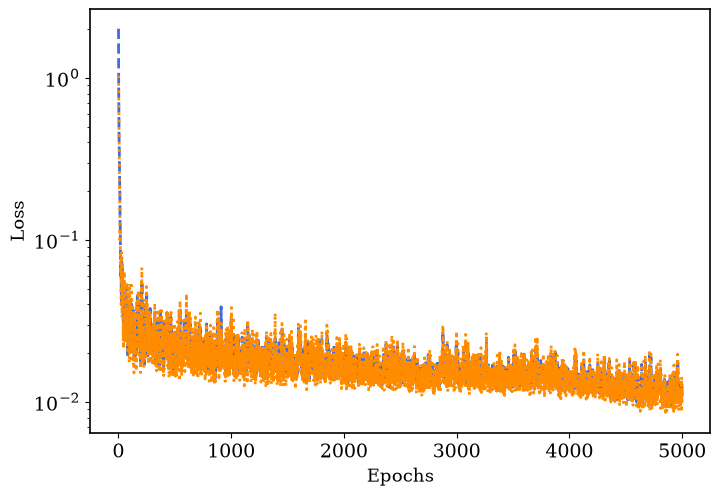

In [ ]:
# BLOCK 11: Paper-style training/validation loss plot (Figure-8 like)

import matplotlib.pyplot as plt

# Optional: run this block only if history is not already available
# (use fewer epochs first to test quickly)
if "history" not in globals():
    print("history not found. Running training now to collect loss curves...")
    tf.keras.backend.clear_session()
    model = build_mass_model()
    optimizer_hist = tf.keras.optimizers.AdamW(learning_rate=final_lr, weight_decay=final_weight_decay)
    model, history = run_training_with_history(
        model,
        optimizer_hist,
        epochs=FINAL_EPOCHS,
        batch_size=final_batch_size,
        weights_cfg=final_cfg,
        verbose_every=500,
        eval_every=1,
    )

plt.figure(figsize=(8, 5.5))
plt.plot(history["epoch"], history["train_loss"], linestyle="-", linewidth=2.0, color="royalblue", label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], linestyle="--", linewidth=2.0, color="darkorange", label="Validation Loss")

plt.yscale("log")
plt.xlabel("Epochs", fontsize=13)
plt.ylabel("Loss", fontsize=13)
plt.grid(True, which="major", linestyle="--", alpha=0.35)
plt.grid(True, which="Loss", linestyle="--", alpha=0.35)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()
